In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
from scipy.ndimage import gaussian_filter1d
import ipywidgets as widgets
from src.analisi.tools import *

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

In [53]:
bilancia_timestamps, bilancia_thicknesses, bilancia_rates = load_bilancia_data(os.path.join(base_img_folder, folder_selector.value, "data", 'points.txt'))
bilancia_timestamps = np.array(bilancia_timestamps)
bilancia_trel = bilancia_timestamps - bilancia_timestamps[0]
print(bilancia_timestamps)
print(bilancia_timestamps.shape)

[1.78049603e+09 1.78049603e+09 1.78049603e+09 ... 1.78049622e+09
 1.78049622e+09 1.78049622e+09]
(4255,)


In [4]:
#raccolgiamo le immagini per calcolare le intensità medie 

images, image_timestamps = load_images_from_folder(os.path.join(base_img_folder, folder_selector.value, 'images'))
images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)

image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
image_seconds = np.array(image_seconds)

image_trel = image_seconds - image_seconds[0]

In [52]:
print(image_seconds.shape)
print(image_seconds)

(1076,)
[1.78049603e+09 1.78049603e+09 1.78049603e+09 ... 1.78049710e+09
 1.78049710e+09 1.78049710e+09]


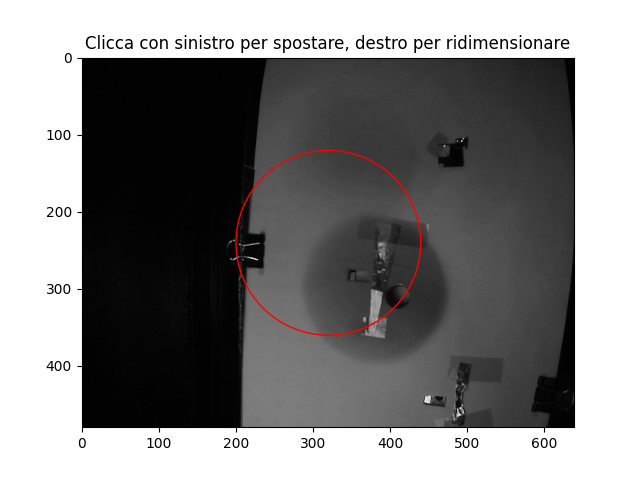

In [6]:
roi_select = RoiSelectorWidget(images[-1])

In [7]:
roi_center, roi_radius = roi_select.roi

In [8]:
def build_roi(im0, center_x, center_y, radius):
    
    h, w = im0.shape[:2]
    Y, X = np.ogrid[:h, :w]
    
    dist_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    
    mask = dist_from_center <= radius
    
    return mask

def extract_roi_from_images(images, mask):
    return [image * mask for image in images]

def compute_mean(images, roi_mask):
    return [np.mean(image[roi_mask > 0]) for image in images]

def compute_diff_imgs(images, reference_image):
    return [reference_image - image for image in images]

In [9]:
reference_image = np.mean(images[:10], axis=0) if images else None
roi_mask = build_roi(reference_image, roi_center[0], roi_center[1], roi_radius)
roi_images = extract_roi_from_images(images, roi_mask)
reference_image_roi = extract_roi_from_images([reference_image], roi_mask)[0]
difference_images = compute_diff_imgs(roi_images, reference_image_roi)
mean_intensities = np.array(compute_mean(difference_images, roi_mask))

In [35]:
window_size = 10
sigma = window_size / 2


difference_images_smooth = moving_average_images_gaussian_weights(difference_images, window_size, sigma)
#mean_intensities_smooth = np.mean(images_smooth, axis=(1, 2))
mean_intensities_smooth = np.array(compute_mean(difference_images_smooth, roi_mask))

In [36]:
cut_start_data = (image_trel>100) & (image_trel<1070)
image_trel_cut = image_trel[cut_start_data]
mean_intensities_smooth_cut = mean_intensities_smooth[cut_start_data]

In [37]:
print(mean_intensities_smooth_cut.shape)

(969,)


In [ ]:
#mean_intensities_smooth_sp = gaussian_filter1d(mean_intensities, sigma=5, mode='nearest')

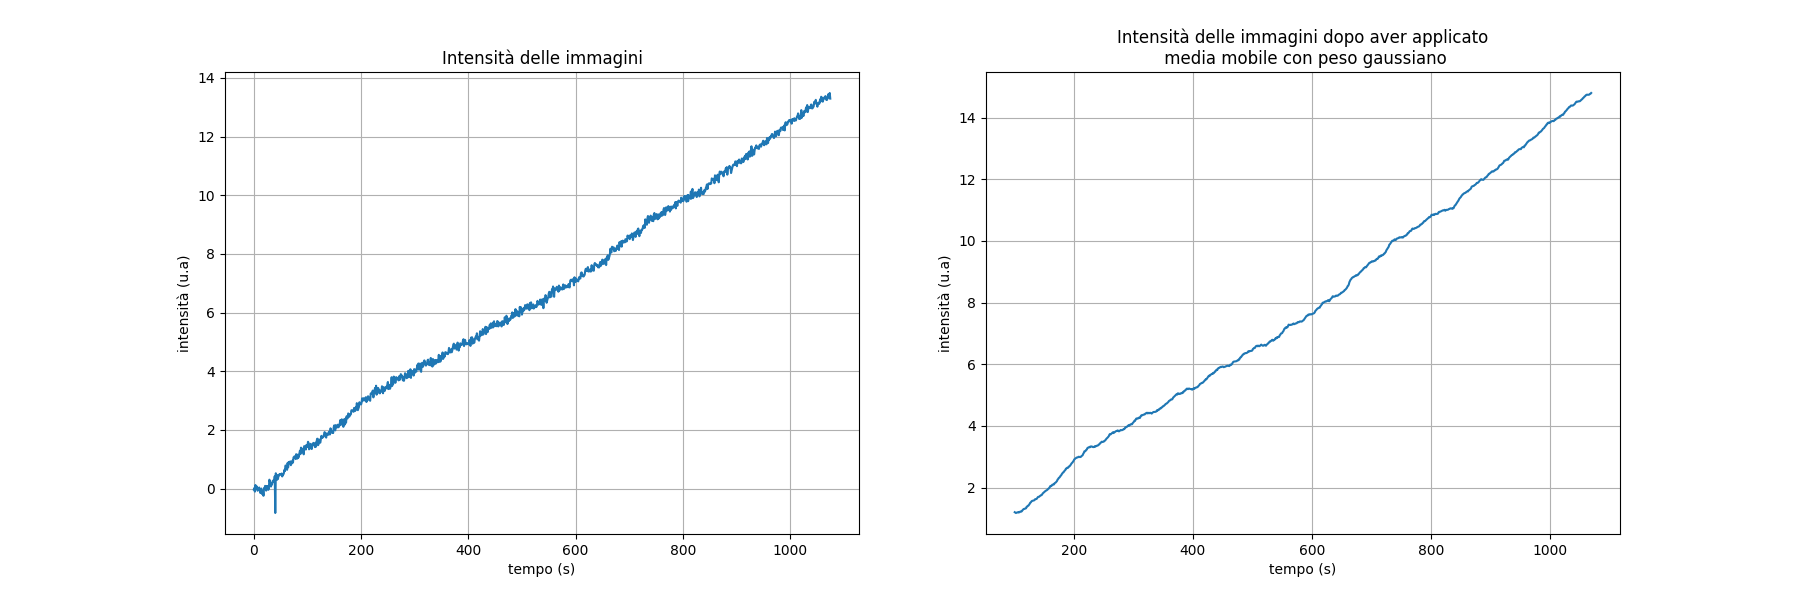

In [38]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(18,6))

ax1.plot(image_trel, mean_intensities)
ax1.set_title("Intensità delle immagini")
ax1.set_ylabel("intensità (u.a)")
ax1.set_xlabel("tempo (s)")
ax1.grid()

ax2.plot(image_trel_cut, mean_intensities_smooth_cut)
ax2.set_title("Intensità delle immagini dopo aver applicato\n media mobile con peso gaussiano")
ax2.set_ylabel("intensità (u.a)" )
ax2.set_xlabel("tempo (s)")
ax2.grid()

"""ax3.plot(image_seconds - image_seconds[0], mean_intensities_smooth_sp)
ax3.set_title("Intensità delle immagini dopo aver applicato\n un filtro gaussiano di scipy")
ax3.set_ylabel("intensità (u.a)")
ax3.set_xlabel("tempo (s)")
ax3.grid()"""


plt.show()

In [14]:
print(mean_intensities[-1] - mean_intensities[0])

13.323665128543176


In [16]:
print(image_seconds[0])
print(image_seconds.shape)
print(bilancia_timestamps[0])
print(bilancia_timestamps.shape)
print(bilancia_trel[0])
print(bilancia_trel.shape)


1780496026.0
(1076,)
1780496033.8412511
(4255,)
0.0
(4255,)


In [39]:
print(bilancia_timestamps[-1])
print(image_seconds[-1])

print(bilancia_trel[-1])
print(image_trel_cut[-1])


1780496219.9603376
1780497101.0
186.11908650398254
1069.0


In [ ]:
"""t0 = bilancia_timestamps[0]
tf = bilancia_timestamps[-1]


time_mask = (image_seconds >= t0) & (image_seconds <= tf)
image_seconds_masked = image_seconds[time_mask]
mean_intensities_masked = mean_intensities[time_mask]"""


In [40]:
print(image_trel.shape)
print(image_trel_cut.shape)
print(bilancia_trel.shape)
print(mean_intensities_smooth_cut.shape)

(1076,)
(969,)
(4255,)
(969,)


In [55]:
t0 = bilancia_trel[0]
tf = bilancia_trel[-1]

time_mask = (image_trel_cut >= t0) & (image_trel_cut <= tf)
image_trel_masked = image_trel_cut[time_mask]
mean_intensities_masked = mean_intensities_smooth_cut[time_mask]

In [ ]:
t0 = image_trel[0]
tf = image_trel[-1]

time_mask = (bilancia_trel>=t0) & (bilancia_trel<=tf)
bilancia_thicknesses

In [ ]:
#bilancia_trel = bilancia_timestamps - t0
#image_trel = image_seconds_masked - t0

In [42]:
print(bilancia_trel.shape)
print(image_trel_masked.shape)
print(mean_intensities_masked.shape)

(4255,)
(86,)
(86,)


In [56]:
# dati di intensità della camera limitati al tempo di misura della bilancia
interpolated_thicknesses = np.interp(bilancia_trel, image_trel_masked, mean_intensities_masked) 

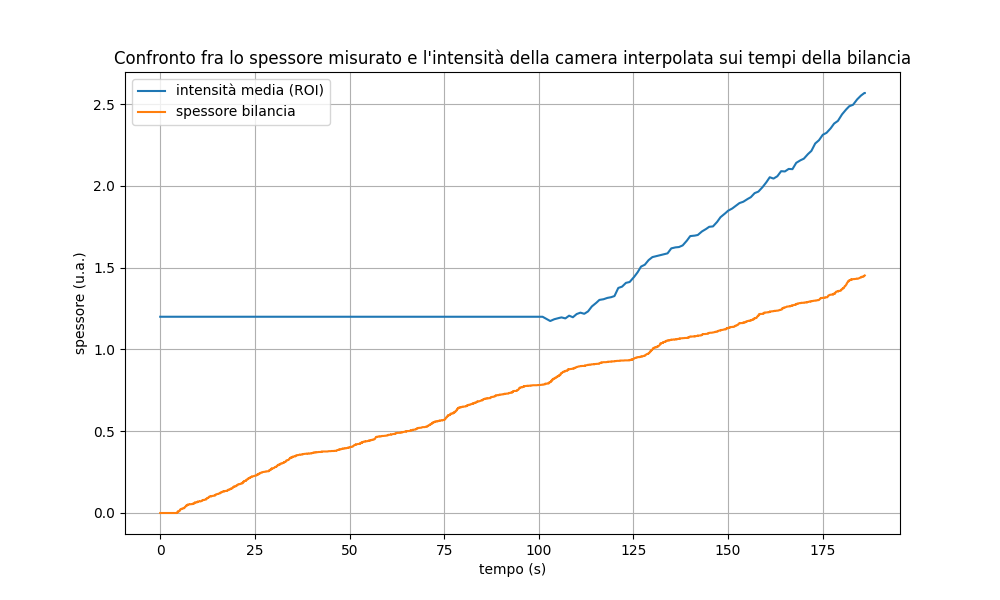

In [57]:
plt.figure(figsize=(10, 6))

plt.plot(bilancia_trel, interpolated_thicknesses, label='intensità media (ROI)')
plt.plot(bilancia_trel, bilancia_thicknesses, label='spessore bilancia')
plt.title("Confronto fra lo spessore misurato e l'intensità della camera interpolata sui tempi della bilancia")
plt.xlabel("tempo (s)")
plt.ylabel("spessore (u.a.)")
plt.legend()
plt.grid()
plt.show()

In [58]:
# m e q forniscono i fattori di scala fra i dati raccolti dalla bilancia e quelli raccolti dalla camera
m, q = np.polyfit(interpolated_thicknesses, bilancia_thicknesses, 1)
print(f"Coefficiente angolare: {m}, intercetta: {q}")

Coefficiente angolare: 0.8340004036117298, intercetta: -0.48967811820354656


In [59]:
slope, intercept, error = lin_fit_with_error(interpolated_thicknesses, bilancia_thicknesses)
print(slope,intercept)

0.8340004036117298 -0.48967811820354656


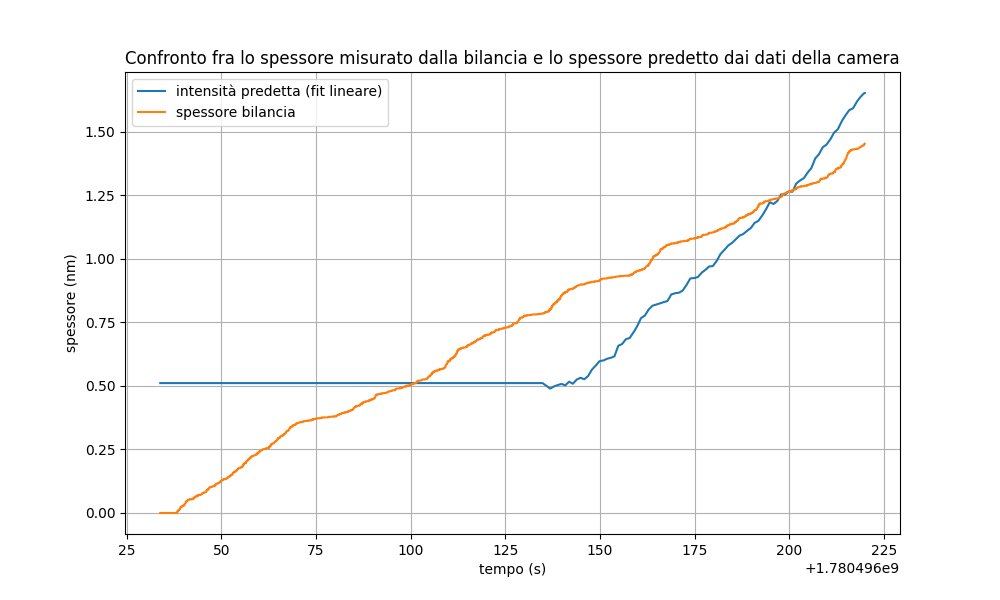

In [60]:
plt.figure(figsize=(10, 6))

predicted_thicknesses = m * interpolated_thicknesses + q # questo è il dato di intensità "convertito" in spessore 

plt.plot(bilancia_timestamps, predicted_thicknesses, label='intensità predetta (fit lineare)')

plt.plot(bilancia_timestamps, bilancia_thicknesses, label='spessore bilancia')

plt.xlabel('tempo (s)')
plt.ylabel('spessore (nm)') #era segnato lo spessore in mm, ho corretto in nm, era una svista?
plt.title("Confronto fra lo spessore misurato dalla bilancia e lo spessore predetto dai dati della camera")
plt.grid()
plt.legend()
plt.show()

0.25713613034332566


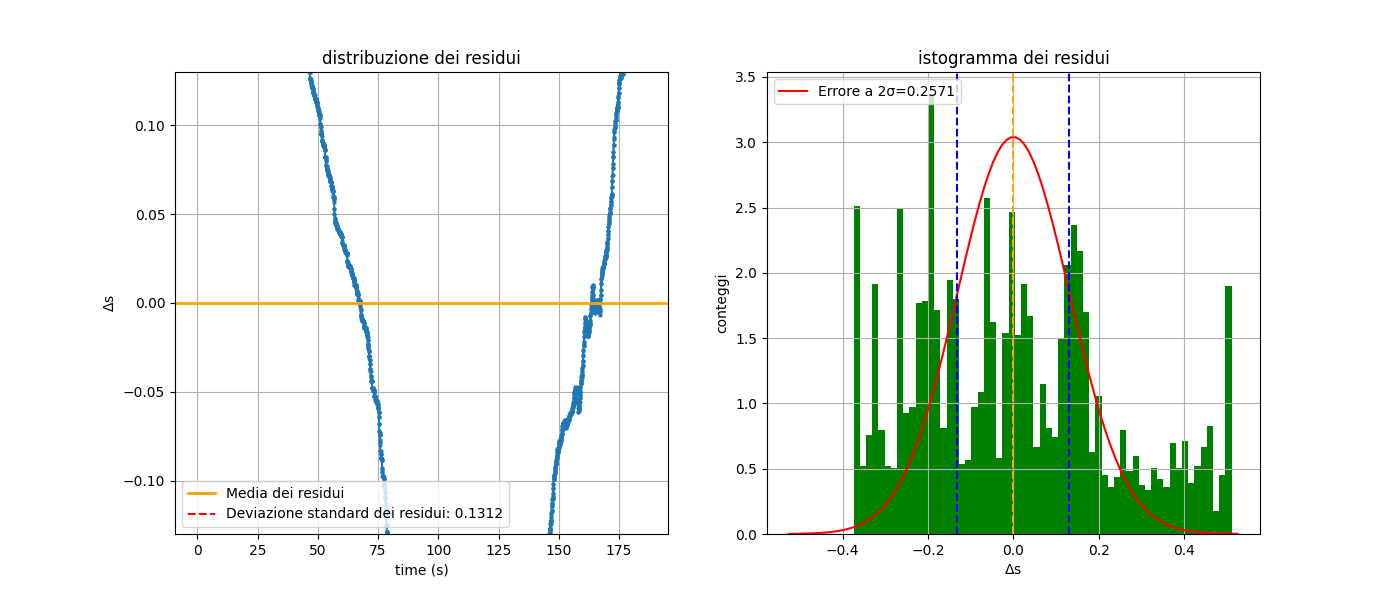

In [29]:
residui = predicted_thicknesses - bilancia_thicknesses



predicted_thicknesses_std = np.std(abs(residui))  # deviazione standard dei residui del fit lineare
media_residui = np.mean(residui)

error_2sigma = 1.96*predicted_thicknesses_std
print(error_2sigma)

Nbins = N = round(len(residui)/70)

fig1, (ax1,ax2) = plt.subplots(1,2, figsize=(14,6))

ax1.plot(bilancia_trel, residui, marker='o', markersize='2')
ax1.set_title("distribuzione dei residui")
ax1.set_ylabel("$\Delta$s")
ax1.set_ylim(bottom=-0.13, top=0.13) #RICORDARSI DI COMMENTARE LA "CADUTA" DEI DATI INTORNO A 30 S SE RIUSCIAMO A SPIEGARLA
ax1.set_xlabel("time (s)")
ax1.axhline(media_residui, color="orange", linestyle="-", label=f'Media dei residui', linewidth=2)
ax1.axhline(predicted_thicknesses_std, color="r", linestyle="--", label=f'Deviazione standard dei residui: {predicted_thicknesses_std:.4f}')
ax1.axhline(-predicted_thicknesses_std, color="r", linestyle='--')
ax1.legend()
ax1.grid()


ax2.hist(residui, Nbins, density=True, color='green')
ax2.set_ylabel("conteggi")
ax2.set_xlabel("$\Delta$s")
ax2.set_title("istogramma dei residui")
ax2.grid()

xs = np.linspace(-4*predicted_thicknesses_std, 4*predicted_thicknesses_std, 100)
ys = (1 / (predicted_thicknesses_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs) / predicted_thicknesses_std) ** 2)
ax2.plot(xs, ys, color='r' )
ax2.plot([], [], color='r', label=f'Errore a 2σ={error_2sigma:.4f}')
ax2.axvline(media_residui, color="orange", linestyle="--")
ax2.axvline(predicted_thicknesses_std, color="b", linestyle="--")
ax2.axvline(-predicted_thicknesses_std, color="b", linestyle='--')

ax2.legend(loc='upper left')
plt.show()

In [ ]:
print("time passed", bilancia_timestamps[-1] - bilancia_timestamps[0])
print("bilancia_thicknesses", bilancia_thicknesses[-1] - bilancia_thicknesses[0])
print("average rate", (bilancia_thicknesses[-1] - bilancia_thicknesses[0]) / (bilancia_timestamps[-1] - bilancia_timestamps[0]))

In [ ]:
avg_rate = (4.5- 0) / (17*60)
avg_rate_min = avg_rate * 60

print(f"Average deposition rate: {avg_rate:.4f} nm/s")
print(f"Average deposition rate: {avg_rate_min:.4f} nm/min")

In [ ]:
thicknesses_from_smooth_camera_data = m * mean_intensities_smooth_sp + q # questi sono gli spessori predetti dalla camera
thicknesses_from_camera_data = m * mean_intensities + q

plt.figure(figsize=(10, 6))

plt.plot(image_seconds - image_seconds[0], thicknesses_from_camera_data, label='Predicted Thickness (All camera data)', color='cyan')
plt.plot(image_seconds - image_seconds[0], thicknesses_from_smooth_camera_data, label='Predicted Thickness (All smooth camera data)', color='magenta')
plt.plot(bilancia_trel, bilancia_thicknesses, color="blue")
plt.title("Spessore equivalente predetto dalla camera")
plt.xlabel("tempo (s)")
plt.ylabel("spessore (u.a.)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
m1, q1 = np.polyfit(image_seconds - image_seconds[0],thicknesses_from_camera_data,1)
print(m1,q1)

In [ ]:
plt.figure(figsize=(10, 6))

rates = np.gradient(bilancia_thicknesses, bilancia_timestamps)

plt.hist(rates, label='Bilancia Rates', color='red')

mean_rate = np.mean(rates[rates >= 0])  # Consider only positive rates for mean calculation
plt.axhline(mean_rate, color='blue', linestyle='--', label=f'Mean Rate: {mean_rate:.2f} mm/s')
print("mean_rate", mean_rate)  # Convert to mm/s


plt.show()